## Business Problem

Telecommunication companies face significant revenue loss due to customer churn. Retaining existing customers is more cost-effective than acquiring new ones, making churn prediction a critical business priority.

## Objective

The goal of this project is to develop a machine learning model that predicts customers likely to churn and identifies the key factors driving churn behavior.

## Success Metric

The model prioritizes recall to ensure that the majority of at-risk customers are identified for proactive retention strategies.

In [2]:
%cd /content/drive/MyDrive/ML_Portfolio/Customer-churn-ML

[Errno 2] No such file or directory: '/content/drive/MyDrive/ML_Portfolio/Customer-churn-ML'
/home/emeka/projects/ML_Portfolio/Customer-churn-ML/notebooks


In [3]:
# ----- Data Handling ------
import pandas as pd
import numpy as np

# ----- Visualization ------
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)


In [4]:
# import dataset
# Verify the contents of the 'data' directory
!ls '/content/drive/MyDrive/ML_Portfolio/Customer-churn-ML/data/'
df = pd.read_csv(r'/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/telco_churn.csv')
df.head()

ls: cannot access '/content/drive/MyDrive/ML_Portfolio/Customer-churn-ML/data/': No such file or directory


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **Initial Observation:**
###- Dataset contains customer-level telecom data
### - Columns include demographic, service usage, and billing information
### - Target variable 'Churn' indicates whether a customer left

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Dataset Summary (from `df.info()`):

- **Total Entries:** 7043
- **Total Columns:** 21
- **Data Types:**
  - `object`: 18 columns
  - `int64`: 2 columns
  - `float64`: 1 column
- `TotalCharges` is of type `object` and should likely be numeric, which might indicate hidden missing values or parsing issues. This will need further investigation and cleaning

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Missing Values:** No explicitly missing values shown by `Non-Null Count` for any column

In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## **Observations:**
 - Dataset is imbalanced (more non-churn than churn)
- This may affect model performance and evaluation

# **Data Cleaning**

In [8]:
# Convert to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Create a copy of original dataset before cleaning
df_copy = df.copy()

In [9]:
# Remove leading/trailing spaces from categorical columns
for col in df_copy.select_dtypes(include='object').columns:
    df_copy[col] = df_copy[col].str.strip()

In [10]:
# Check duplicates
df_copy.duplicated().sum()

np.int64(0)

In [11]:
# check for inconsistent values
for col in df_copy.select_dtypes(include='object').columns:
    print(col, df_copy[col].unique())
    print('\n')

customerid ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']


gender ['Female' 'Male']


partner ['Yes' 'No']


dependents ['No' 'Yes']


phoneservice ['No' 'Yes']


multiplelines ['No phone service' 'No' 'Yes']


internetservice ['DSL' 'Fiber optic' 'No']


onlinesecurity ['No' 'Yes' 'No internet service']


onlinebackup ['Yes' 'No' 'No internet service']


deviceprotection ['No' 'Yes' 'No internet service']


techsupport ['No' 'Yes' 'No internet service']


streamingtv ['No' 'Yes' 'No internet service']


streamingmovies ['No' 'Yes' 'No internet service']


contract ['Month-to-month' 'One year' 'Two year']


paperlessbilling ['Yes' 'No']


paymentmethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


totalcharges ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']


churn ['No' 'Yes']




In [12]:
df_copy[df_copy['monthlycharges'] == 0]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn


In [13]:
# Fix logical inconsistency:
# Customers with tenure = 0 should have totalcharges = 0
df_copy.loc[df_copy['tenure'] == 0, 'totalcharges'] = 0

In [14]:
df_copy[(df_copy['internetservice'] == 'No') & (df_copy['onlinesecurity'] == 'Yes')]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn


In [15]:
df_copy['totalcharges'] = pd.to_numeric(df_copy['totalcharges'], errors='coerce')

In [16]:
df_copy.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# **Data Cleaning Summary:**
 - Standardized column names
 - Created a working copy of dataset
 - Converted totalcharges to numeric and handled missing values
 - Checked and removed duplicates (if any)
 - Ensured consistency in categorical values
 - Validated numerical columns and logical consistency
 - Prepared dataset for exploratory analysis

# **EDA**

## Business Objective

The objective of this project is to analyze customer churn behavior in a telecommunications company and develop a machine learning solution capable of predicting customers likely to churn.

This analysis focuses on identifying:
- Customer segments with high churn risk
- Service-related drivers of churn
- Revenue-related churn patterns
- Behavioral indicators associated with customer retention

The findings from this analysis will support proactive customer retention strategies.

In [17]:
df_copy.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# create working DataFrame for EDA
eda_df = df_copy.copy()

### **Target Variable Analysis**

In [19]:
# Check the number of customers in each churn category
eda_df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [20]:
# Check churn percentage distribution

eda_df['churn'].value_counts(normalize=True) * 100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

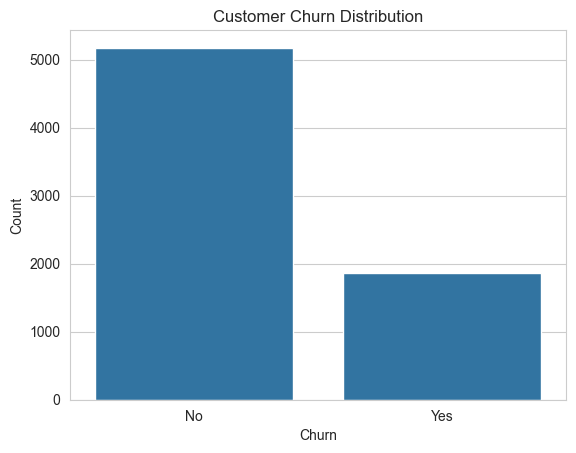

In [21]:
# Visualize churn distribution

sns.countplot(data=eda_df, x='churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

### Target Variable Insight

The dataset contains a higher proportion of retained customers (73.46%) compared to churned customers (26.54%).

This indicates a moderate class imbalance in the target variable, where non-churned customers significantly outnumber churned customers.

From a business perspective, identifying customers likely to churn is critically important because customer retention is generally more cost-effective than acquiring new customers.

### **Numeric Feature Analysis**

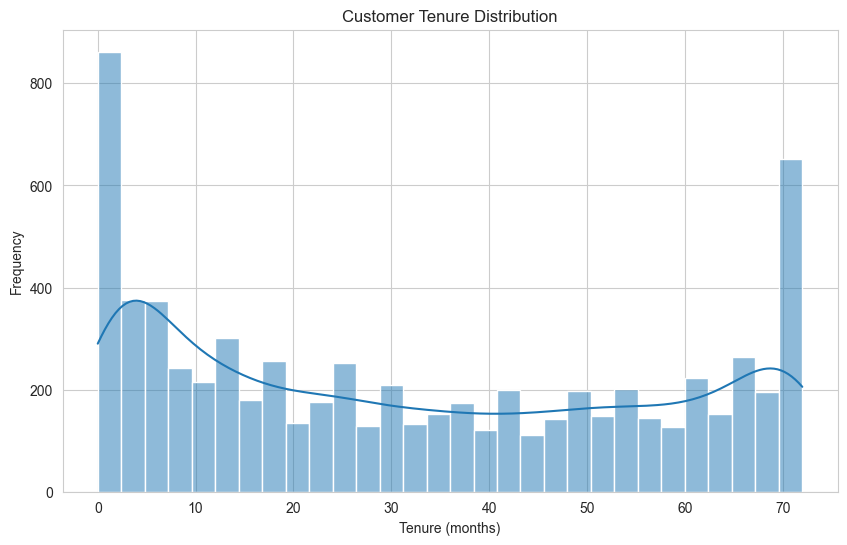

In [22]:
# Analyze customer tenure distribution

plt.figure(figsize=(10, 6))
sns.histplot(data=eda_df, x='tenure' , bins=30, kde=True)
plt.title('Customer Tenure Distribution')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.show()

### Tenure Distribution Insight

The tenure distribution exhibits a non-normal pattern with noticeable concentration at both low and high tenure levels.

A significant proportion of customers have very short tenure, suggesting that many customers either recently joined the service or tend to churn during the early stages of subscription.

Another concentration appears among long-tenure customers, indicating the presence of loyal customers who maintain long-term relationships with the company.

The relatively lower concentration of mid-tenure customers may suggest a transition pattern where customers either churn early or remain long enough to become stable subscribers.

### Additional Analytical Observation

The relatively lower concentration of customers in the mid-tenure range may indicate that some customers churn before reaching long-term loyalty status.

This pattern could potentially reflect customer dissatisfaction factors such as pricing concerns, service quality issues, or unmet expectations during the customer lifecycle.

Another possible explanation is the presence of onboarding incentives for new customers and retention benefits for long-term subscribers, which may contribute to higher customer concentration at both early and late tenure stages.

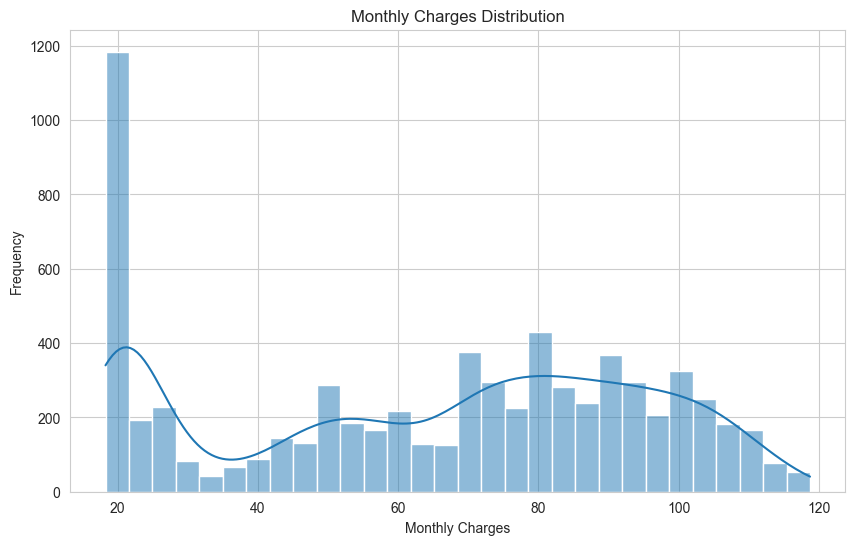

In [23]:
# Analyze monthly charges distribution

plt.figure(figsize=(10, 6))
sns.histplot(data=eda_df, x='monthlycharges', bins=30, kde=True)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()

### Monthly Charges Distribution Insight

The monthly charges distribution exhibits multiple concentration peaks, suggesting the presence of several customer pricing tiers and service package categories.

Lower charge ranges likely represent customers subscribed to basic telecom services, while higher charge ranges may correspond to customers using premium or bundled services such as fiber internet, streaming platforms, online security, and technical support.

The clustering pattern indicates that customers tend to subscribe to specific service combinations rather than uniformly distributed pricing plans.

This distribution also suggests the existence of distinct customer segments based on service consumption and pricing preferences.

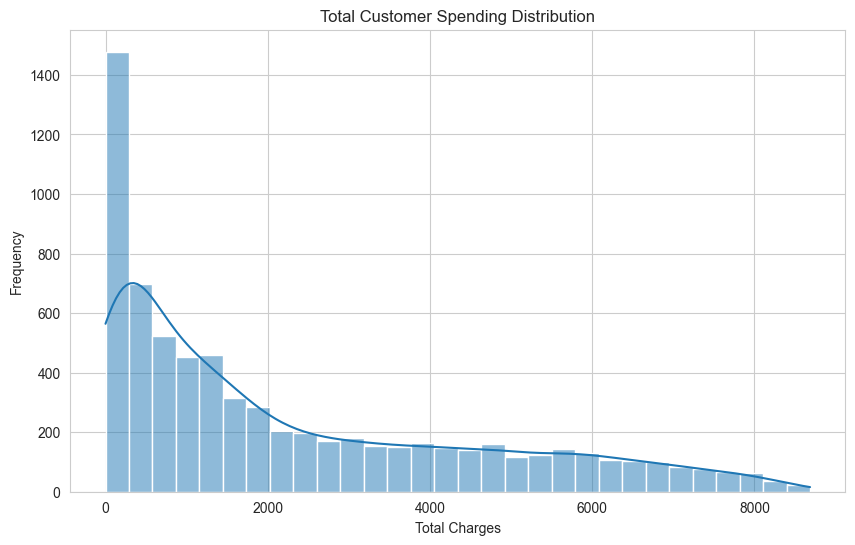

In [24]:
# Analyze total customer spending distribution

plt.figure(figsize=(10, 6))
sns.histplot(data=eda_df, x='totalcharges', bins=30, kde=True)
plt.title('Total Customer Spending Distribution')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()


### Total Charges Distribution Insight

The total charges distribution exhibits strong positive skewness, with a large concentration of customers within the lower spending range.

This pattern suggests that many customers either have relatively short tenure or have not accumulated substantial long-term spending with the company.

A smaller group of customers contributes very high total charges, likely representing long-tenure and high-value customers with greater customer lifetime value.

The extended right tail indicates the presence of a valuable loyal customer segment that may contribute significantly to overall company revenue.

In [26]:
# Summary statistics for numerical features

eda_df[['tenure', 'monthlycharges', 'totalcharges']].describe()

,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### Statistical Summary Insight

The numerical features exhibit varying distribution patterns and levels of variability across customers.

The `tenure` feature shows substantial variation in customer retention behavior, with customers ranging from newly subscribed users to long-term loyal subscribers. The mean tenure is slightly higher than the median, suggesting mild positive skewness driven by long-tenure customers.

`monthlycharges` demonstrates moderate variability, indicating the presence of multiple pricing tiers and service package categories across customers. The relatively small difference between the mean and median suggests a more balanced distribution compared to other numerical features.

`totalcharges` exhibits strong positive skewness, with a large concentration of customers in the lower spending range and a smaller group of high-value customers contributing substantially higher cumulative revenue. The large standard deviation further indicates significant variation in customer lifetime value.

Overall, the statistical summary suggests the presence of multiple customer segments with distinct retention behavior, pricing structures, and spending patterns.

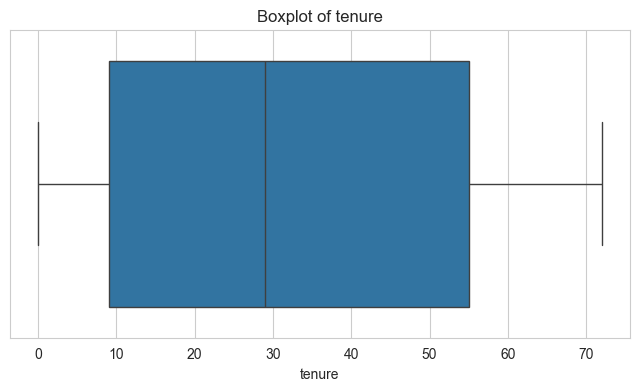

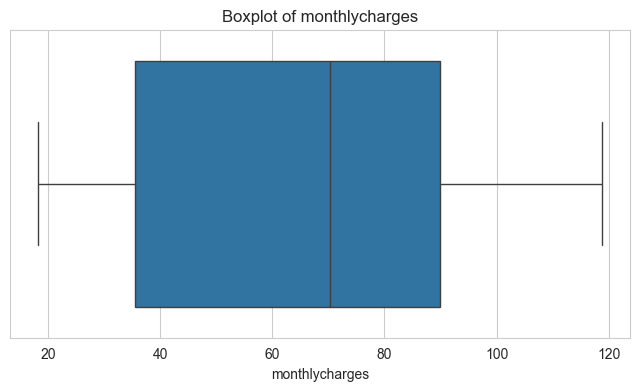

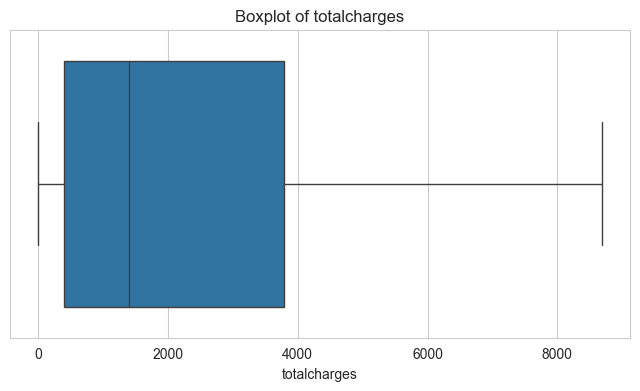

In [28]:
# Visualize numerical feature spread and potential outliers

numerical_features = ['tenure', 'monthlycharges', 'totalcharges']
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=eda_df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.show()

### Boxplot Analysis Insight

The boxplots indicate substantial variability across the numerical features, particularly in `tenure` and `totalcharges`, reflecting diverse customer retention and spending behaviors.

No significant extreme outliers were observed beyond the whisker boundaries, suggesting that the observed high-value ranges are likely legitimate customer behaviors rather than data quality issues.

The elongated spread in `totalcharges` further reinforces the presence of customers with substantially different lifetime value profiles, while `monthlycharges` exhibits comparatively more stable pricing variation across customers.

### **Bivariate Analysis**

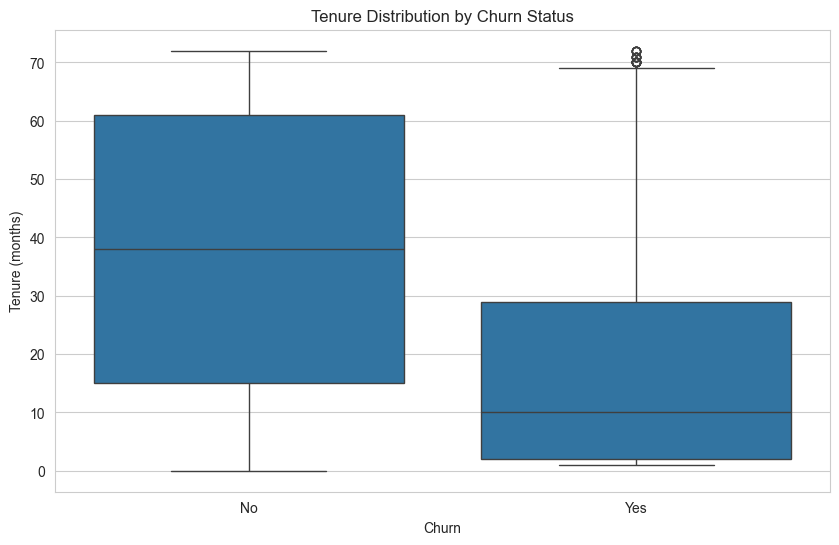

In [29]:
# Compare tenure distribution across churn groups

plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='tenure', data=eda_df)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.show()


### Tenure vs Churn Insight

Customers who churn exhibit substantially lower tenure compared to retained customers, with most churned customers concentrated within the early stages of the customer lifecycle.

The median tenure for churned customers is significantly lower than that of retained customers, suggesting that churn risk is highest during the initial subscription period.

This pattern indicates that long-term customers are generally more stable and less likely to leave the service, potentially due to increased customer satisfaction, switching costs, loyalty incentives, or long-term service integration.

The findings also suggest the presence of customer lifecycle risk, where customers are more vulnerable to churn before establishing long-term commitment to the service.

From a business perspective, improving onboarding experience, customer engagement, and early retention incentives may help reduce churn during the critical early stages of subscription, where retention interventions are often more cost-effective than reacquiring lost customers.

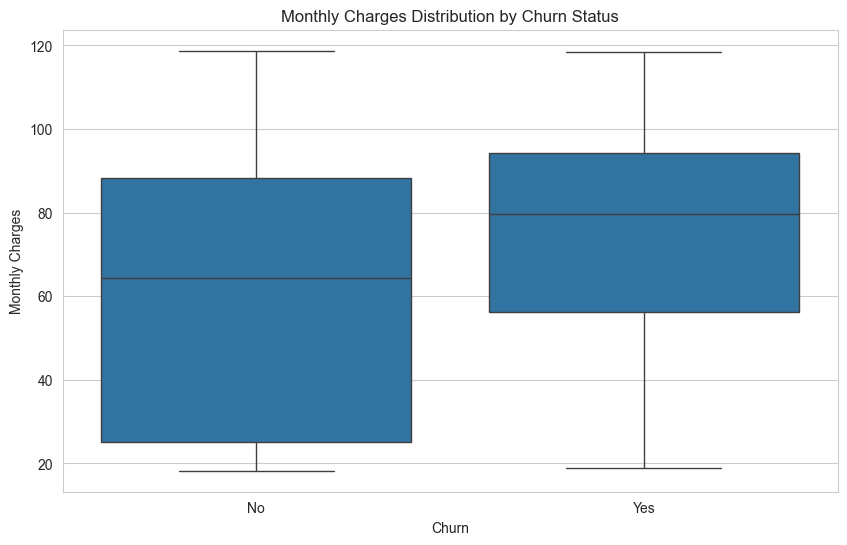

In [30]:
# Compare monthly charges across churn groups

plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='monthlycharges', data=eda_df)
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### Monthly Charges vs Churn Insight

Customers who churn generally exhibit higher monthly charges compared to retained customers, indicating that pricing and premium service usage may contribute significantly to churn behavior.

The higher median monthly charges among churned customers suggest that customers paying for more expensive or bundled services may possess greater sensitivity to perceived service quality, pricing fairness, or competitive alternatives.

This relationship may be especially important during the early stages of the customer lifecycle, where customers have not yet fully integrated the company’s services into their routines and may therefore face lower switching barriers.

The findings also suggest that premium customers likely maintain higher service expectations and lower tolerance for poor customer experience or dissatisfaction relative to the value received.

From a business perspective, improving perceived service value, enhancing customer support quality, and implementing targeted retention incentives for high-paying customers may help reduce churn among premium customer segments.

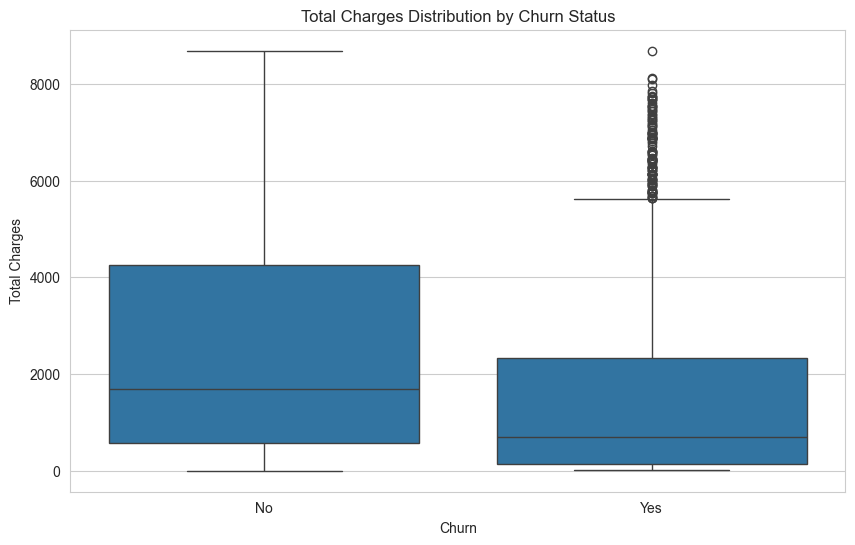

In [31]:
# Compare total charges across churn groups
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='totalcharges', data=eda_df)
plt.title('Total Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
plt.show()